C:\Users\ewq95\AppData\Local\Temp\ipykernel_14140\1290332844.py:74: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\ewq95\miniconda3\envs\DL\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


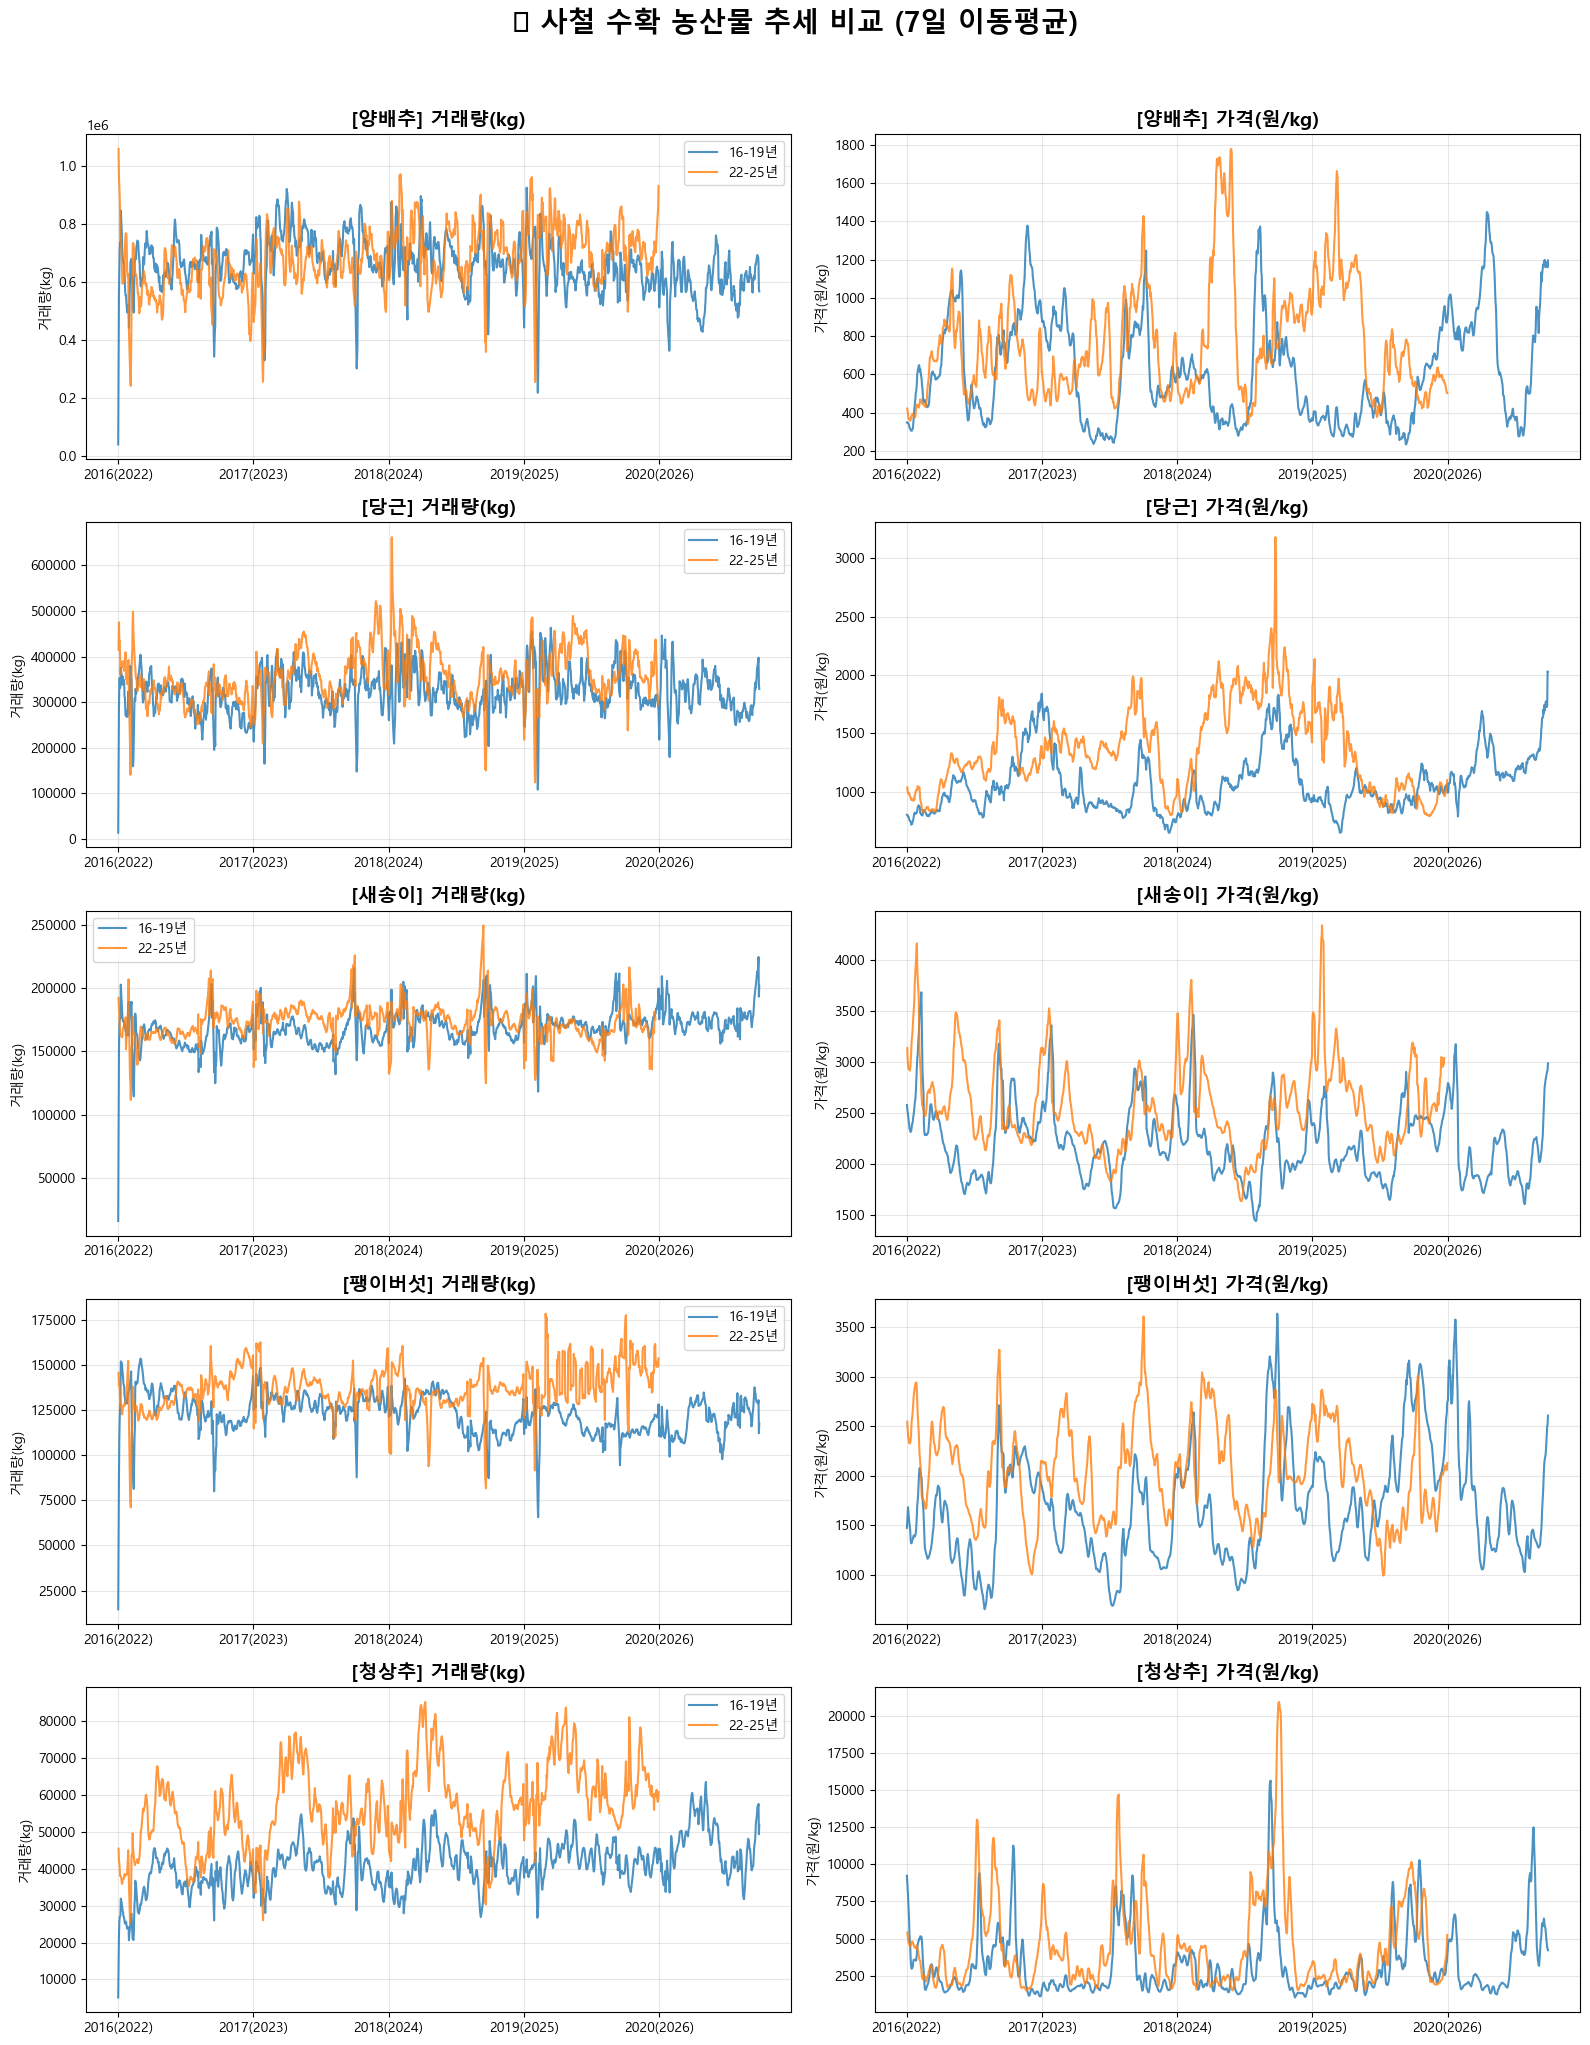

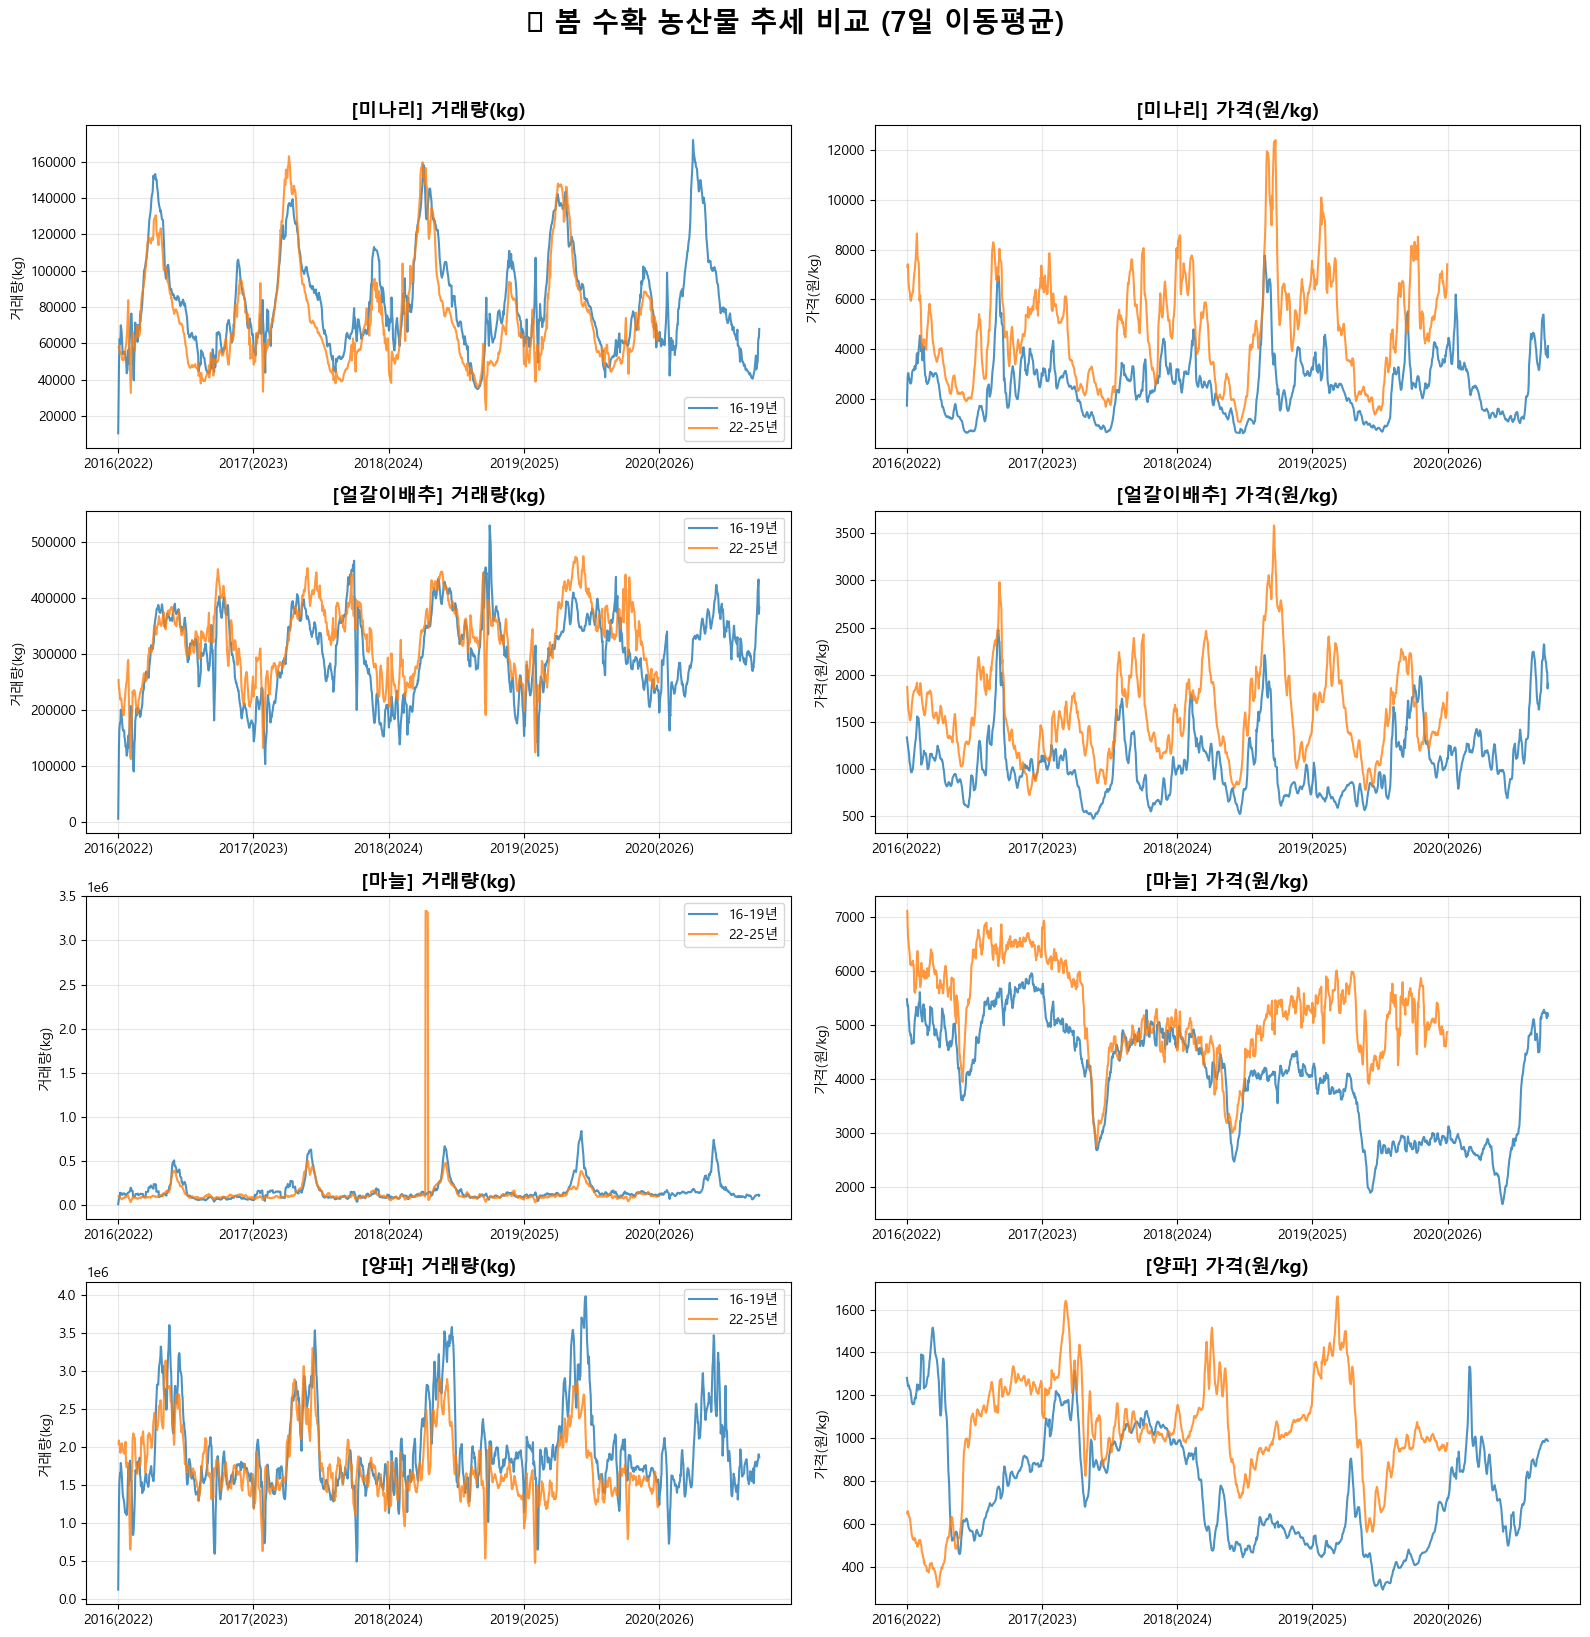

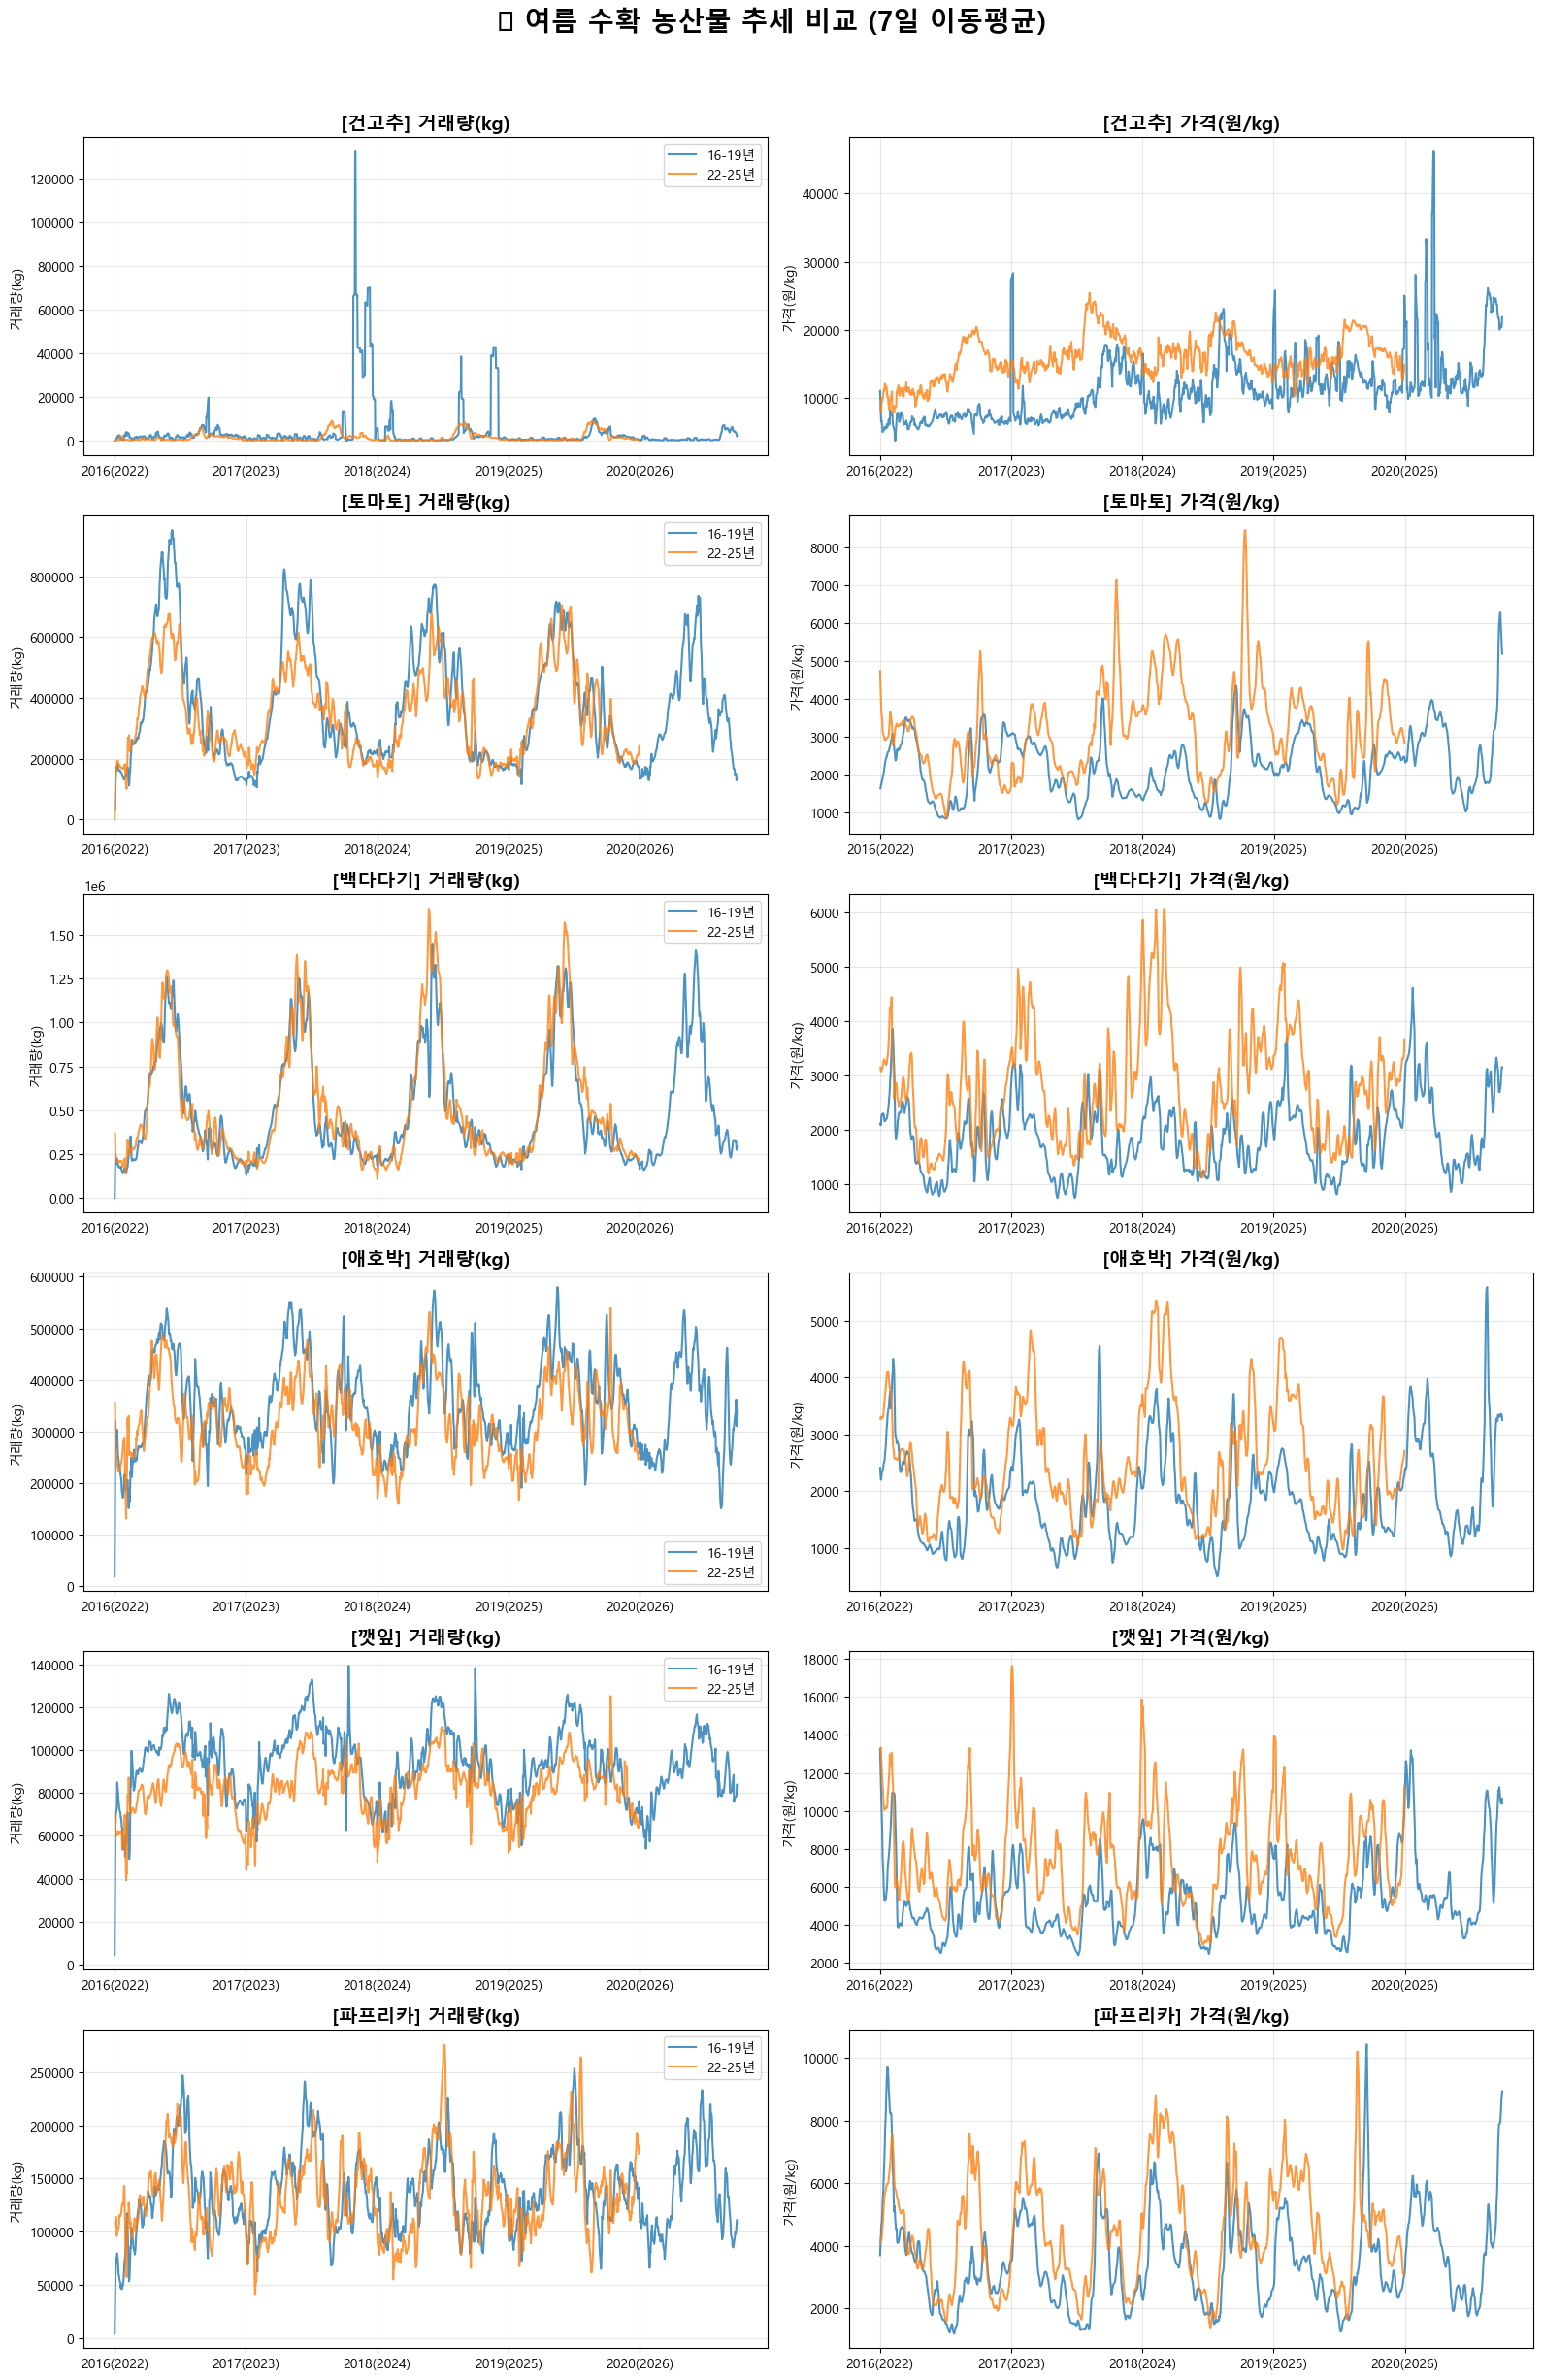

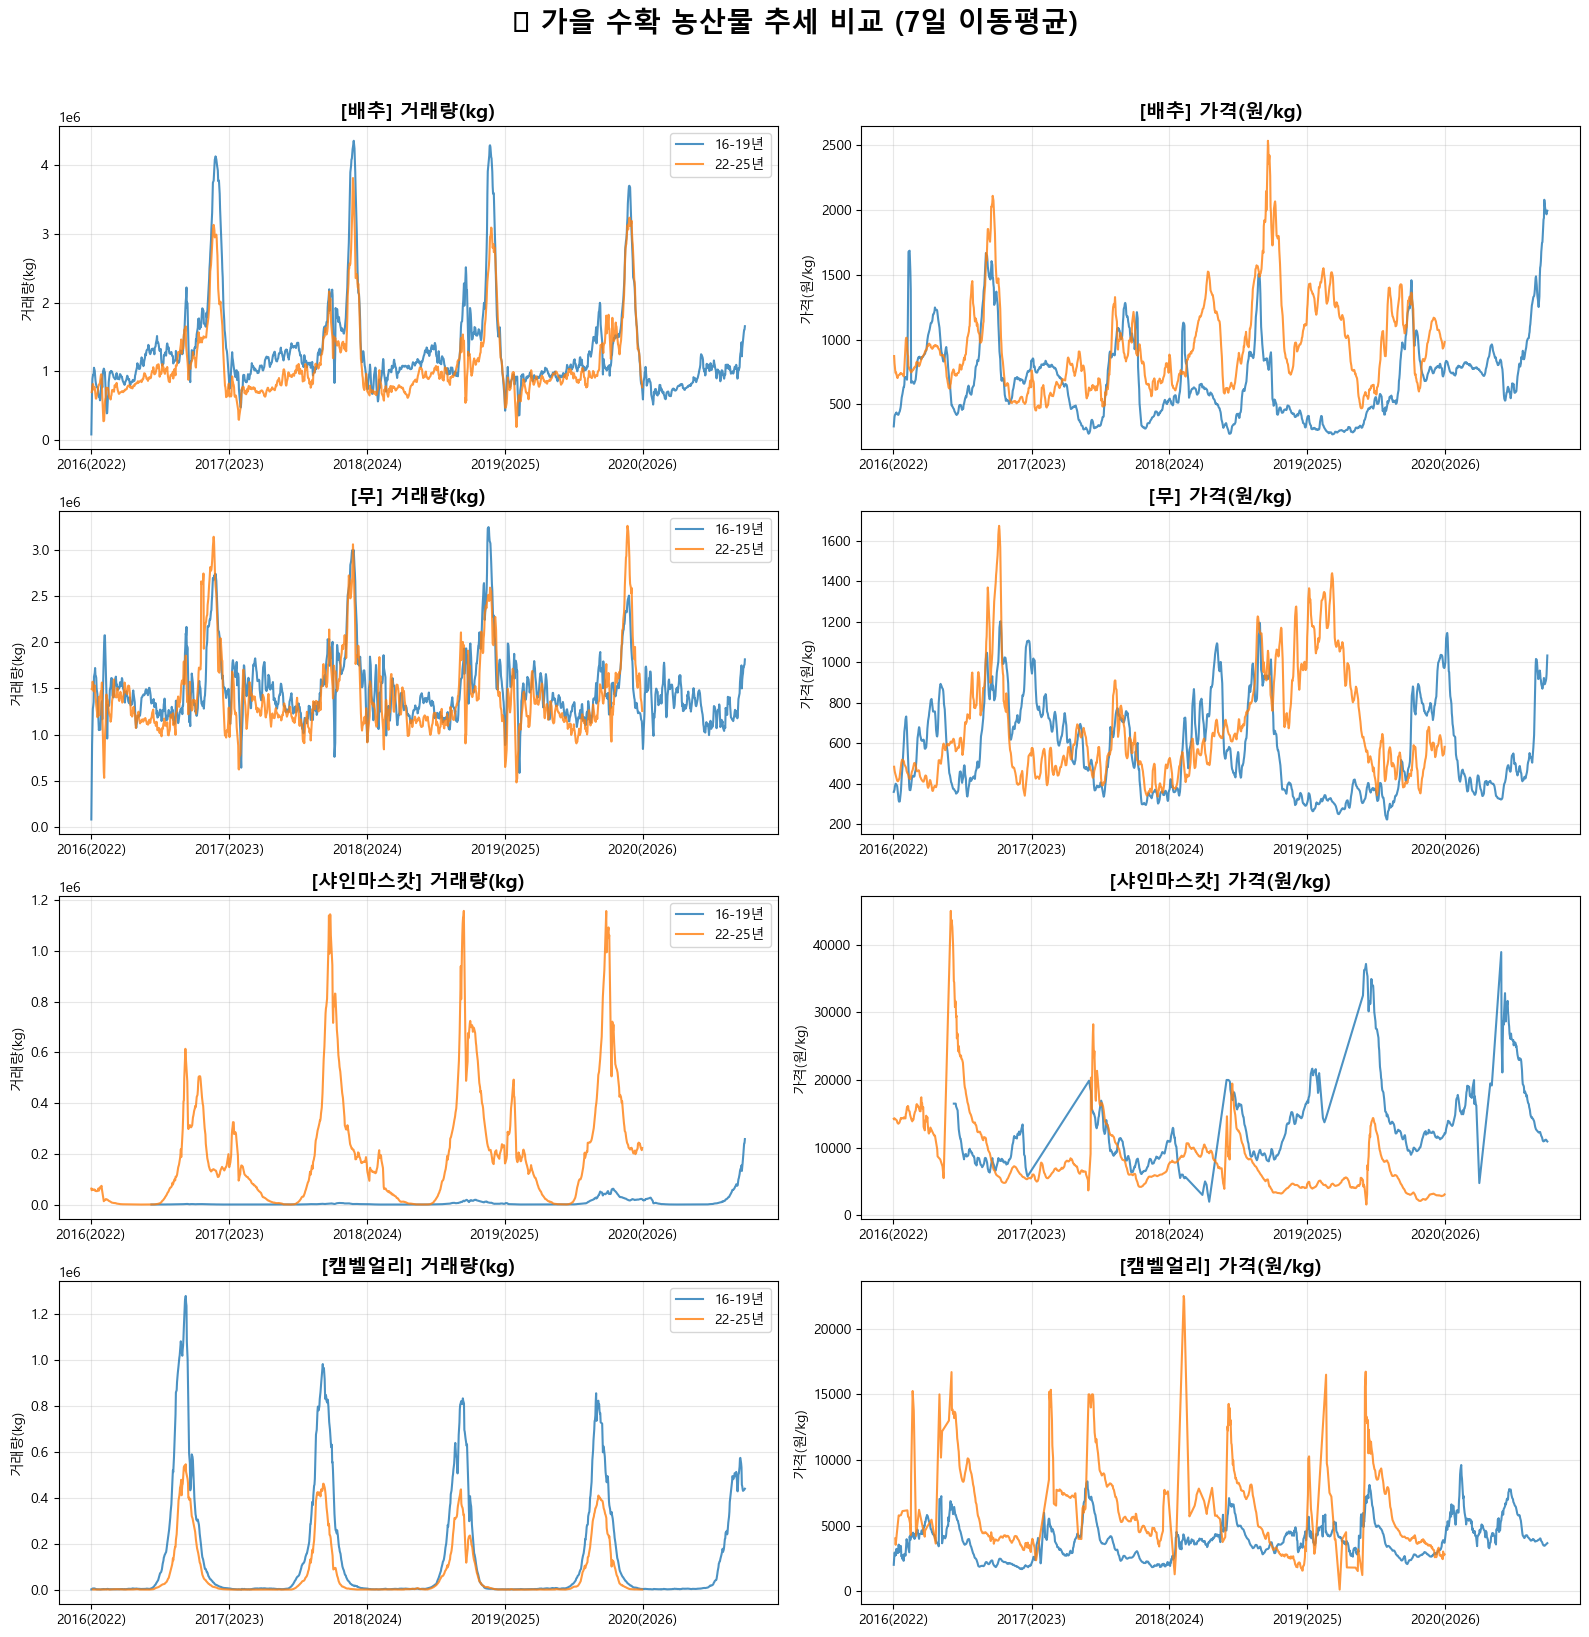

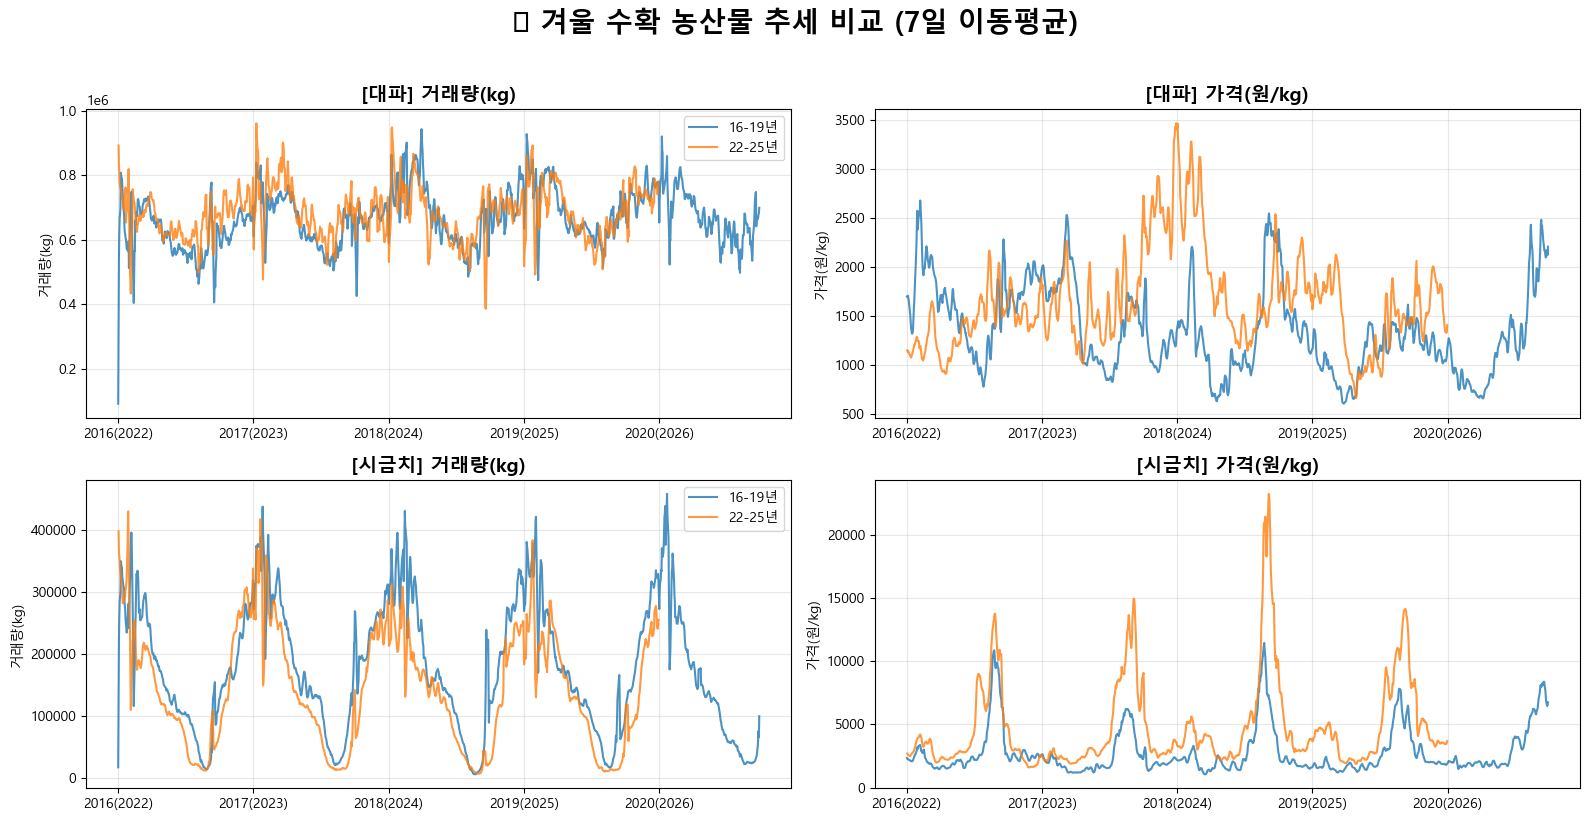

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker  # 💡 ticker 모듈 추가!

# 🎨 한글 폰트 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기 
df1 = pd.read_csv('train.csv')
df2 = pd.read_csv('train22.csv')

# 날짜 형식으로 변환 ('date' 컬럼)
df1['date'] = pd.to_datetime(df1['date'])
df2['date'] = pd.to_datetime(df2['date'])

# 22-25년 데이터 날짜에서 6년 빼기
df2['매핑날짜'] = df2['date'] - pd.DateOffset(years=6)

# 계절별 농산물 리스트
seasonal_crops = {
    '사철': ['양배추', '당근', '새송이', '팽이버섯', '청상추'],
    '봄': ['미나리', '얼갈이배추', '마늘', '양파'],
    '여름': ['건고추', '토마토', '백다다기', '애호박', '깻잎', '파프리카'],
    '가을': ['배추', '무', '샤인마스캇', '캠벨얼리'],
    '겨울': ['대파', '시금치']
}
metrics = ['거래량(kg)', '가격(원/kg)']

for season, crops in seasonal_crops.items():
    n_crops = len(crops)
    fig, axes = plt.subplots(nrows=n_crops, ncols=2, figsize=(16, 4 * n_crops), squeeze=False)
    fig.suptitle(f"🌱 {season} 수확 농산물 추세 비교 (7일 이동평균)", fontsize=20, fontweight='bold', y=1.02)
    
    for i, crop in enumerate(crops):
        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            col_name = f"{crop}_{metric}"
            
            if col_name not in df1.columns or col_name not in df2.columns:
                ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center', fontsize=12)
                ax.set_title(f"[{crop}] {metric}")
                continue
                
            temp1 = df1[['date', col_name]].copy()
            temp1 = temp1[temp1[col_name] > 0].sort_values('date')
            
            temp2 = df2[['매핑날짜', col_name]].copy()
            temp2 = temp2[temp2[col_name] > 0].sort_values('매핑날짜')
            
            temp1.set_index('date', inplace=True)
            temp2.set_index('매핑날짜', inplace=True)
            
            temp1['ma7'] = temp1[col_name].rolling('7D').mean()
            temp2['ma7'] = temp2[col_name].rolling('7D').mean()
            
            ax.plot(temp1.index, temp1['ma7'], label='16-19년', alpha=0.8, color='tab:blue')
            ax.plot(temp2.index, temp2['ma7'], label='22-25년', alpha=0.8, color='tab:orange')
            
            ax.set_title(f"[{crop}] {metric}", fontsize=14, fontweight='bold')
            ax.set_ylabel(metric, fontsize=10)
            ax.grid(True, alpha=0.3)
            
            # 💡 X축 연도 병기 포맷팅 (YYYY(YYYY+6) 형태) - ticker.FuncFormatter로 수정!
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.xaxis.set_major_formatter(
                ticker.FuncFormatter(lambda x, pos: f"{mdates.num2date(x).year}({mdates.num2date(x).year + 6})")
            )
            
            if j == 0:
                ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()